In [1]:
import geopandas as gpd
from pyproj import Geod
import numpy as np
from esda.moran import Moran
import libpysal
from esda.moran import Moran_Local
import rasterio

C:\Users\ACER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\libpysal\io\iohandlers\__init__.py:25: UserWarning: SQLAlchemy not installed, database I/O disabled
  warnings.warn("SQLAlchemy not installed, database I/O disabled")  # noqa: B028


In [2]:
gdf = gpd.read_file(r'F:\pomelo\Shape file-20251216T041154Z-3-001\moransI\residualMoransI.shp')

In [4]:
gdf.columns

Index(['OBJECTID', 'TYPE_3', 'provincial', 'district_l', 'comuune_le',
       'urban_divi', 'provinci_1', 'GR_SID', 'SID', 'total_numb', 'Total_popu',
       'Shape_Leng', 'Shape_Area', 'pred_pop', 'residual', 'area_ha',
       'pop_dens_1', 'building_c', 'pop_built_', 'geometry'],
      dtype='object')

In [5]:
w = libpysal.weights.KNN.from_dataframe(gdf, k=3)

In [10]:
y = gdf["pop_built_"].values

mi = Moran(y, w)

print("Moran's I:", mi.I)
print("p-value:", mi.p_sim)

Moran's I: 0.03044150432264319
p-value: 0.001


In [9]:
def effective_sample_size(n, morans_I):
    n_hat = n * (
        1 - (1 / (1 - np.exp(-1.92369)))
        * ((n - 1) / n)
        * (1 - np.exp(-2.12373 * morans_I + 0.20024 * np.sqrt(morans_I)))
    )
    return int(n_hat)

In [14]:
lisa = Moran_Local(gdf["Total_popu"], w)
gdf["totalPop_pValue"] = lisa.p_sim

In [13]:
size = effective_sample_size(len(gdf), mi.I) * 2

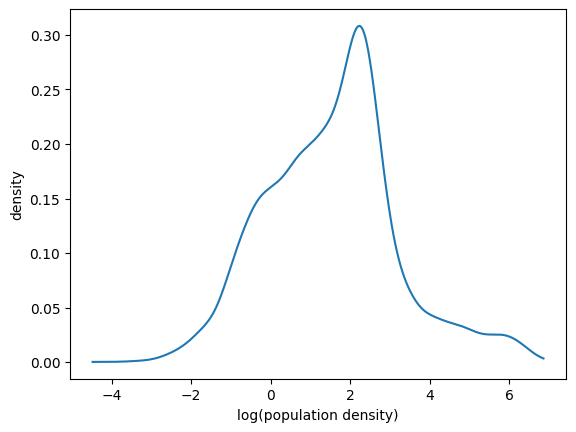

In [37]:
import numpy as np
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt
# Get data
data = gdf['pop_dens_1']
data = data[data > 0]

# Compute log
log_data = np.log(data)

kde = gaussian_kde(log_data)
x = np.linspace(log_data.min(), log_data.max(), 500)
y = kde(x)

plt.plot(x, y)
plt.xlabel("log(population density)")
plt.ylabel("density")
plt.show()

In [22]:
gdf.to_file(r'F:\pomelo\Shape file-20251216T041154Z-3-001\moransI\residualMoransI.shp', driver='ESRI Shapefile')

C:\Users\ACER\AppData\Local\Temp\ipykernel_20592\1156780422.py:1: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf.to_file(r'F:\pomelo\Shape file-20251216T041154Z-3-001\moransI\residualMoransI.shp', driver='ESRI Shapefile')
C:\Users\ACER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'building_counts' to 'building_c'
  ogr_write(
C:\Users\ACER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'pop_built_up_dens' to 'pop_built_'
  ogr_write(
